# Analise comportamental com dados

### Importacao das libs

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

### Carregando dados

In [43]:
dados = pd.read_csv("data/Lab2_T2_-_Conversas_exportadas.tsv", sep="\t")
dados['Timestamp'] = pd.to_datetime(dados['Timestamp'])

dados_formulario = pd.read_csv("data/Respostas_exportadas_Turma2.csv", sep="\t", index_col=0)
dados_formulario = dados_formulario.rename_axis("Pessoa")

## Comportamental

### Visão individual

<Axes: xlabel='Timestamp'>

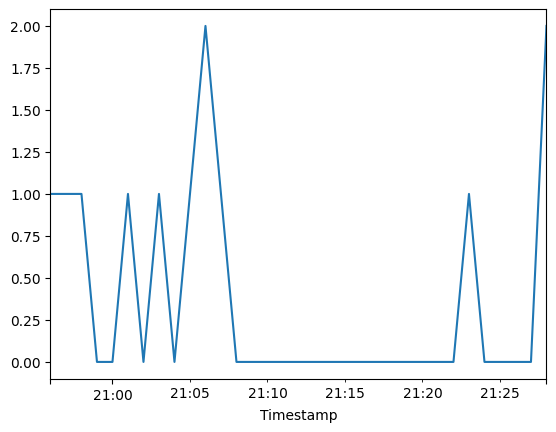

In [44]:
comportamental = []

for username in dados['Username'].unique():
  dados_filtrados = dados[dados['Username'] == username]
  dados_filtrados = dados_filtrados.set_index("Timestamp")
  B_t = dados_filtrados.resample("1min")['Message'].count().to_frame()
  B_t['Pessoa'] = username
  B_t['Grupo'] = dados_filtrados['Group'].iloc[0]
  B_t = B_t.reset_index()
  comportamental.append(B_t)

comportamental = pd.concat(comportamental)
comportamental[comportamental['Pessoa']=='usuario962'].set_index("Timestamp")['Message'].plot()

### Visão geral por grupos

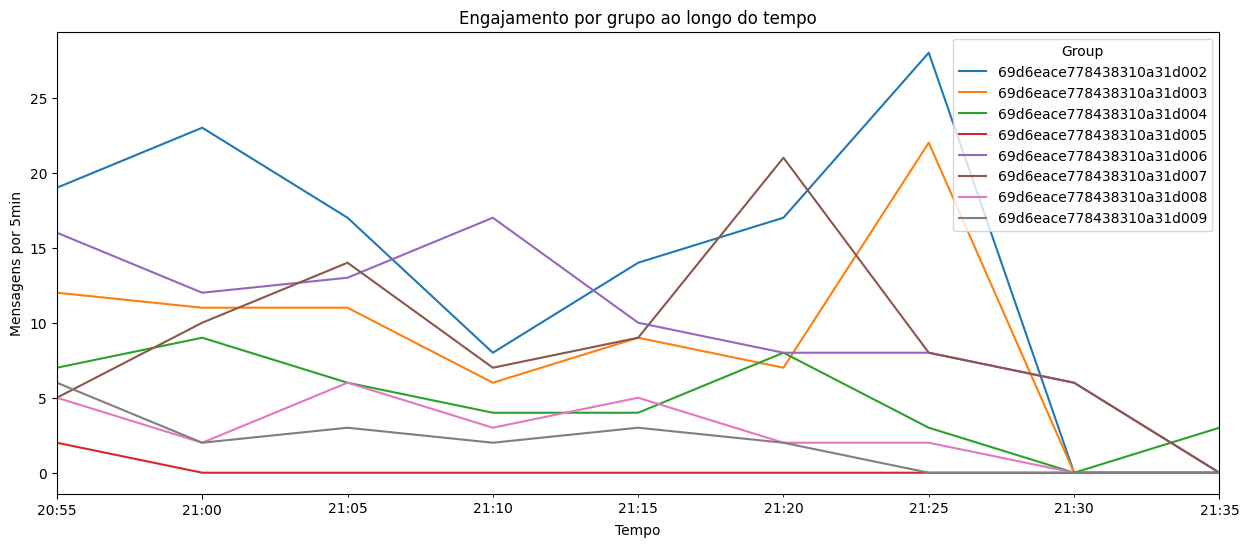

In [45]:
engajamento_grupo = (
    dados.set_index("Timestamp")
         .groupby("Group")["Message"]
         .resample("5min")
         .count()
         .unstack(level=0)
         .fillna(0)
)

engajamento_grupo.plot(figsize=(15,6))
plt.title("Engajamento por grupo ao longo do tempo")
plt.xlabel("Tempo")
plt.ylabel("Mensagens por 5min")
plt.show()

## Afetiva

### Rastreio de Emoções

In [46]:
emocoes = {
    "negativo": [
        # confusão / dificuldade
        "não entendi", "n entendi", "não saquei", "n saquei",
        "estou confuso", "to confuso", "tô confuso",
        "boiei", "viajei", "perdi aqui", "me perdi",
        "isso tá confuso", "tá complicado", "complicado isso",
        "difícil de entender", "não ficou claro", "não fez sentido",

        # frustração / erro
        "que droga", "droga", "aff", "afff", "affs",
        "ah não", "ah, não", "ahhh não", "não acredito",
        "deu ruim", "deu errado", "não deu certo",
        "quebrou", "bugou", "travou", "deu erro", "erro aqui",
        "falhou", "não funcionou", "continua dando erro",
        "n funcionou", "não rola", "não vai",

        # desânimo / cansaço
        "cansativo", "que saco", "saco isso", "chato",
        "muito chato", "tá chato", "desanimei",
        "sem paciência", "tô sem paciência", "cansei",
        "preguiça disso", "desisti", "vou desistir",

        # avaliação negativa
        "ruim", "bem ruim", "péssimo", "horrível",
        "muito ruim", "fraco", "mais ou menos", "meh",
        "não gostei", "odiei", "detestei",

        # surpresa negativa / reprovação
        "vish", "ixi", "eita", "eita...", "caramba...",
        "sério isso?", "não faz sentido", "nada a ver",
        "que absurdo", "complicado viu", "tenso",

        # ansiedade / insegurança
        "acho que tá errado", "isso tá estranho",
        "não tenho certeza", "não sei se tá certo",
        "to inseguro", "tô perdido"
    ],

    "positivo": [
        # compreensão / progresso
        "ah, entendi", "agora entendi", "saquei", "agora saquei",
        "ficou claro", "clareou", "fez sentido",
        "agora faz sentido", "peguei a ideia",

        # satisfação
        "legal", "muito legal", "massa", "top", "show",
        "bacana", "daora", "irado", "maneiro",
        "amei", "curti", "gostei", "gostei muito",

        # sucesso
        "deu certo", "funcionou", "agora foi",
        "resolvido", "consegui", "finalmente",
        "agora sim", "perfeito", "tudo certo",
        "rodou", "executou", "passou",

        # agradecimento
        "obrigado", "obg", "valeu", "valeu mesmo",
        "muito obrigado", "agradeço", "tmj",
        "thanks", "vlw", "brigadão",

        # entusiasmo
        "boa", "boa!", "boa demais", "excelente",
        "ótimo", "maravilha", "sensacional",
        "fantástico", "show de bola", "top demais",
        "perfeito mesmo", "ficou ótimo",

        # alívio
        "ufa", "ainda bem", "que bom",
        "menos mal", "resolvido isso",
        "agora fiquei tranquilo",

        # confirmação
        "ok", "ok!", "beleza", "blz", "certo",
        "fechado", "combinado", "isso mesmo",
        "exatamente", "isso aí"
    ],

    "surpresa": [
        "nossa", "caramba", "uau", "incrível",
        "não esperava", "surpreso", "surpresa",
        "sério?", "mentira", "chocado"
    ],

    "raiva": [
        "raiva", "irritado", "irritante", "que ódio",
        "estou bravo", "fiquei bravo", "puto",
        "pistola", "nervoso"
    ],

    "tristeza": [
        "triste", "chateado", "decepcionado", "deprê",
        "depressivo", "desanimado", "desmotivado",
        "desapontado"
    ],

    "medo": [
        "medo", "receio", "preocupado", "ansioso",
        "tenso", "assustado", "apreensivo",
        "inseguro"
    ],
    
    "alegria": [
        "feliz", "alegre", "contente", "animado",
        "empolgado", "satisfeito", "radiante",
        "maravilhado"
    ],
}

### Visão individual

In [47]:

def normalizar(texto):
    import unicodedata
    texto = texto.lower()
    texto = unicodedata.normalize('NFKD', texto)
    texto = texto.encode('ASCII', 'ignore').decode('ASCII')
    return texto

def verificar_emocao(texto):
    texto = normalizar(texto)

    for emocao, termos in emocoes.items():
      for termo in termos:
        if normalizar(termo) in texto:
          return emocao
    return "neutro"

afetivo = []

for username in dados['Username'].unique():
  dados_filtrados = dados[dados['Username'] == username].copy()
  dados_filtrados['Sentimento'] = dados_filtrados['Message'].apply(verificar_emocao)

  sentimentos_lista = list(emocoes.keys())
  sentimento = dados_filtrados['Sentimento'].value_counts().to_frame("count_emocoes").reindex(sentimentos_lista, fill_value=0)
  sentimento['Pessoa'] = username
  sentimento['Grupo'] = dados_filtrados['Group'].iloc[0]
  sentimento = sentimento.reset_index()

  afetivo.append(sentimento)

afetivo = pd.concat(afetivo).reset_index(drop=True)
afetivo = afetivo[['Grupo', 'Pessoa', 'Sentimento', 'count_emocoes']]
#afetivo.head()

afetivo_pivotado = afetivo.pivot(index="Pessoa", columns="Sentimento", values="count_emocoes")
afetivo_pivotado.head()


Sentimento,alegria,medo,negativo,positivo,raiva,surpresa,tristeza
Pessoa,,,,,,,
Clair,0,0,0,0,0,0,0
usario140,0,0,2,1,0,0,0
usuario021,0,0,2,3,0,0,0
usuario032,0,0,0,2,0,0,0
usuario034,0,0,0,0,0,0,0


### Visão por Grupo

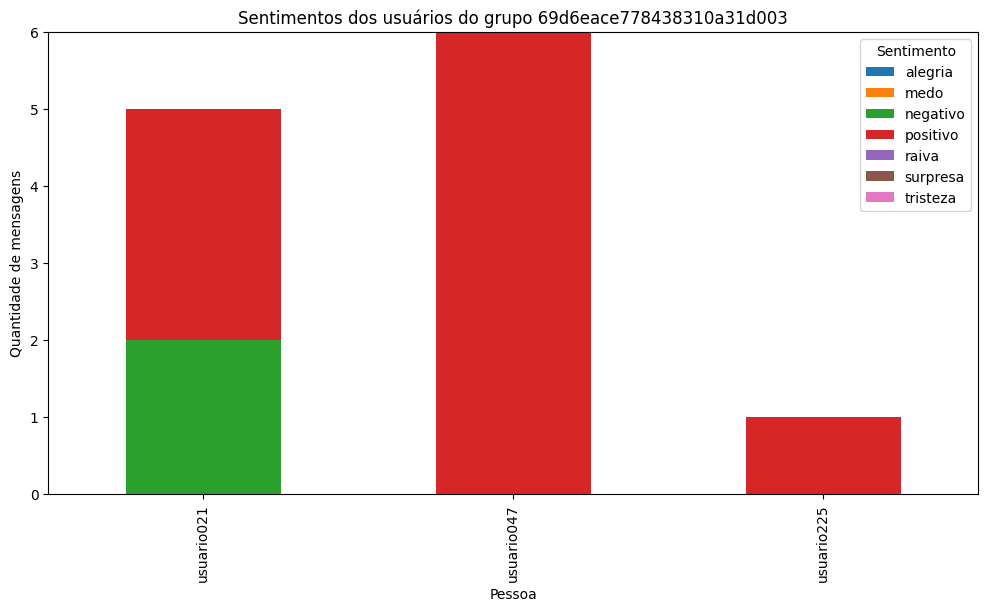

In [48]:
grupo_escolhido = "69d6eace778438310a31d003"
afetivo_grupo = afetivo[afetivo['Grupo'] == grupo_escolhido]

afetivo_grupo_pivot = afetivo_grupo.pivot(index="Pessoa", columns="Sentimento", values="count_emocoes")
afetivo_grupo_pivot

afetivo_grupo_pivot.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title(f"Sentimentos dos usuários do grupo {grupo_escolhido}")
plt.ylabel("Quantidade de mensagens")
plt.show()

### Visão Geral

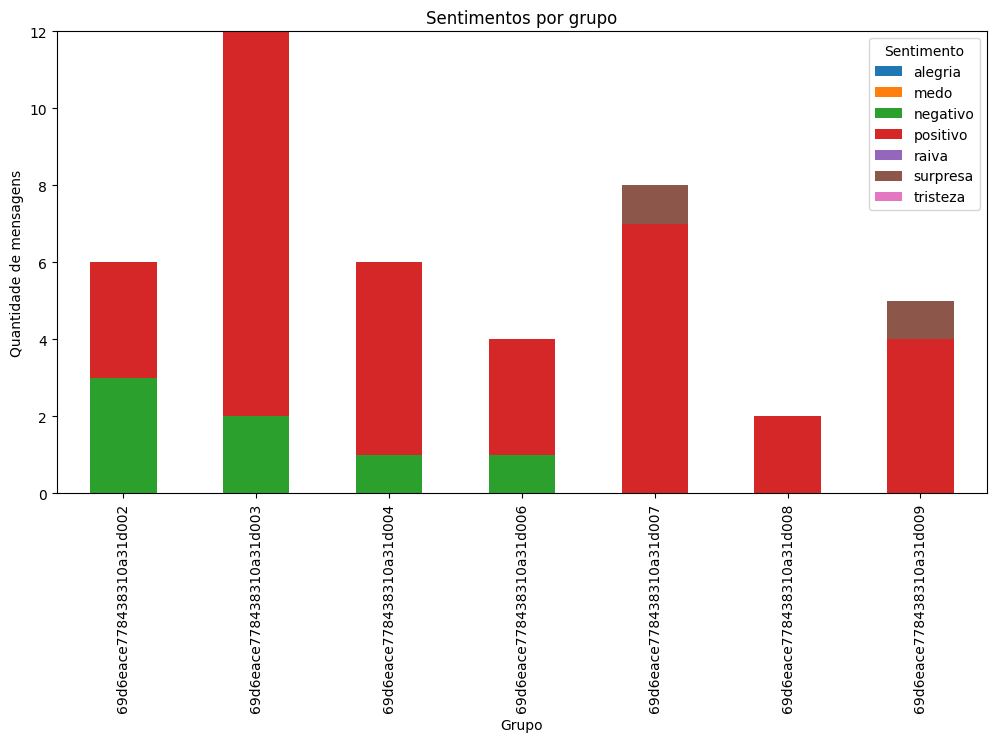

In [49]:
sentimentos_por_grupo = afetivo.groupby(["Grupo", "Sentimento"])["count_emocoes"].sum().unstack().fillna(0)
sentimentos_por_grupo.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Sentimentos por grupo")
plt.ylabel("Quantidade de mensagens")
plt.xlabel("Grupo")
plt.show()

## Cognitiva

### Diversidade Lexical

In [50]:
def contar_diversidade_lexical(dados_filtrados):
  lista_palavras = " ".join(list(dados_filtrados['Message'])).split(" ")
  diversidade_lexical = len(set([ normalizar(palavra) for palavra in lista_palavras ]))
  diversidade_lexical = pd.DataFrame([{"Pessoa": dados_filtrados['Username'].iloc[-1],
                                      "Grupo": dados_filtrados['Group'].iloc[-1],
                                      "diversidade_lexical": diversidade_lexical}])
  return diversidade_lexical.reset_index(drop=True)

cognitivo = dados.groupby("Username")[['Message', 'Username', 'Group']]\
                     .apply(contar_diversidade_lexical)\
                     .reset_index(drop=True)\
                     .rename_axis("index")

a = afetivo_pivotado
b = comportamental.rename(columns={"Username": "Pessoa"}).groupby("Pessoa")['Message'].sum()
c = cognitivo.set_index("Pessoa").drop(columns='Grupo')
engajamento_final = a.join(b).join(c)
engajamento_final = engajamento_final.rename(columns={"Message": "count_msg"})
engajamento_final

,alegria,medo,negativo,positivo,raiva,surpresa,tristeza,count_msg,diversidade_lexical
Pessoa,,,,,,,,,
Clair,0,0,0,0,0,0,0,31,89
usario140,0,0,2,1,0,0,0,28,74
usuario021,0,0,2,3,0,0,0,37,118
usuario032,0,0,0,2,0,0,0,9,17
usuario034,0,0,0,0,0,0,0,3,14
usuario042,0,0,0,1,0,0,0,12,72
usuario047,0,0,0,6,0,0,0,31,98
usuario110,0,0,0,3,0,1,0,28,108
usuario111,0,0,0,2,0,0,0,6,27


### Correlação entre variáveis quantitativas

<Axes: >

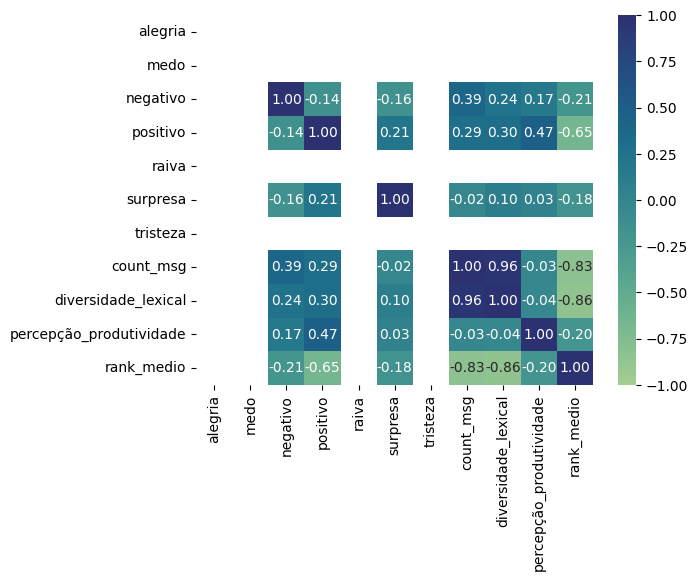

In [51]:
ranks = engajamento_final.rank(method='min', ascending=False)

ranks['negativo'] = engajamento_final['negativo'].rank(method='min')

rank_medio = ranks[['positivo', 'count_msg', 'diversidade_lexical']]\
                .mean(axis=1).to_frame("rank_medio").sort_values('rank_medio')

ranks = engajamento_final.rank(method='min', ascending=False)

ranks['negativo'] = engajamento_final['negativo'].rank(method='min')

rank_medio = ranks[['positivo', 'count_msg', 'diversidade_lexical']]\
                .mean(axis=1).to_frame("rank_medio").sort_values('rank_medio')

respostas = dados_formulario
respostas = respostas[respostas.sum(axis=1)>0]
respostas = respostas.mean(axis=1).to_frame("percepção_produtividade")
respostas.head()

engajamento_final = engajamento_final.join(respostas).dropna()
engajamento_final = engajamento_final.join(rank_medio)

sns.heatmap(engajamento_final.corr(), annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="crest")

### Matriz de p-valores das correlações

C:\Users\Silas\AppData\Local\Temp\ipykernel_22616\1598098814.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = stats.pearsonr(temp_df[col1], temp_df[col2])
C:\Users\Silas\AppData\Local\Temp\ipykernel_22616\1598098814.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = stats.pearsonr(temp_df[col1], temp_df[col2])
C:\Users\Silas\AppData\Local\Temp\ipykernel_22616\1598098814.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = stats.pearsonr(temp_df[col1], temp_df[col2])
C:\Users\Silas\AppData\Local\Temp\ipykernel_22616\1598098814.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = stats.pearsonr(temp_df[col1], temp_df[col2])
C:\Users\Silas\AppData\Local\Temp\ipykernel_22616\1598098814.py:13: ConstantInputWarning: An input a

<Axes: >

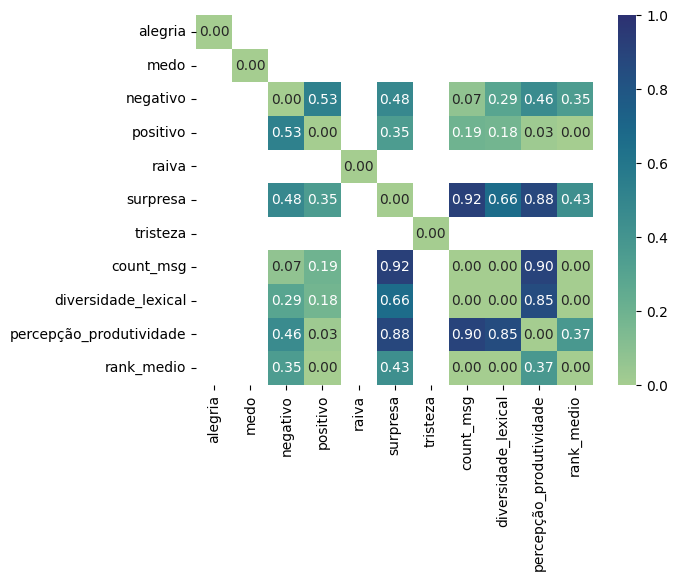

In [52]:
correlation_matrix = engajamento_final.corr()

p_values_matrix = pd.DataFrame(index=engajamento_final.columns, columns=engajamento_final.columns)

for col1 in engajamento_final.columns:
    for col2 in engajamento_final.columns:
        if col1 == col2:
            p_values_matrix.loc[col1, col2] = 0.0 # Correlation with itself is 1, p-value is 0
        else:
            # Drop NaN values for accurate calculation
            temp_df = engajamento_final[[col1, col2]].dropna()
            if len(temp_df) > 1: # Need at least 2 data points for correlation
                corr, p_value = stats.pearsonr(temp_df[col1], temp_df[col2])
                p_values_matrix.loc[col1, col2] = p_value
            else:
                p_values_matrix.loc[col1, col2] = float('nan')

# print("\nP-value Matrix:")
# print(p_values_matrix)
p_values_matrix = p_values_matrix.apply(pd.to_numeric)

sns.heatmap(p_values_matrix, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="crest")